In [1]:
!pip install numpy pandas scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl (350.9 MB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [10]:
data = pd.read_csv("housing.csv")

data.isnull().sum()

data = data.fillna(data.mean())

In [13]:
# 2. Split features and target
X = data.drop("medv", axis=1)
y = data["medv"]

In [14]:
# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# 4. Normalize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# 5. Build Deep Neural Network
model = Sequential()

# Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1))

In [17]:
# 6.Compile Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train model
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)



Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 572.7642 - mae: 21.9747
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 469.6645 - mae: 19.6149
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 322.3884 - mae: 15.8635
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 157.6373 - mae: 10.4394
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 69.4038 - mae: 6.5021
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44.8290 - mae: 5.0574
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.5005 - mae: 4.3805
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29.7454 - mae: 4.0713
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.8018 - mae: 3.8340
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.6129 - mae: 3.6862
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22.9704 - mae: 3.5937
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.4994 - mae: 3.4544
Epoch 13/50
26/26 ━━━━━━━━━━━

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ---------------- LINEAR REGRESSION ----------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

# ---------------- DNN ----------------
dnn_pred = model.predict(X_test).flatten()

dnn_mse = mean_squared_error(y_test, dnn_pred)
dnn_mae = mean_absolute_error(y_test, dnn_pred)

# ---------------- PRINT RESULTS ----------------
print("===== MODEL COMPARISON =====\n")

print("Linear Regression:")
print("MSE:", lr_mse)
print("MAE:", lr_mae)

print("\nDeep Neural Network:")
print("MSE:", dnn_mse)
print("MAE:", dnn_mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
===== MODEL COMPARISON =====

Linear Regression:
MSE: 24.40482518814649
MAE: 3.2064039639003865

Deep Neural Network:
MSE: 12.336922053373831
MAE: 2.3280274849311975


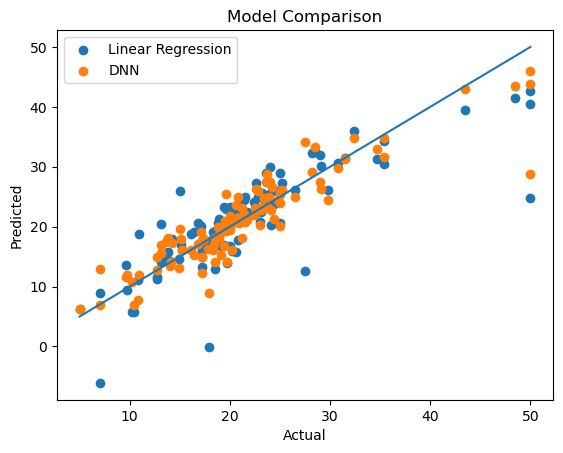

In [19]:
import matplotlib.pyplot as plt


plt.scatter(y_test, lr_pred, label='Linear Regression')
plt.scatter(y_test, dnn_pred, label='DNN')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [20]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
